<a href="https://colab.research.google.com/github/helonayala/sysid/blob/main/lagrange_quarter_drone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1/4 drone example

This script demonstrates a symbolic workflow applies modeling and linearizing a mechanical system, with an application to the 1/4 drone test bench.



## Imports and functions

In [43]:
!pip install control
import sympy as sp
import numpy as np
import control as ct
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.integrate import solve_ivp # Import the standard ODE solver

# Use SymPy's best available renderer for equations
sp.init_printing(use_latex='mathjax')

# --- Helper Functions for Generalization ---

def create_gen_vars(ndof, t):
    """Creates symbolic generalized coordinates, velocities, and accelerations."""
    q = sp.Matrix([sp.Function(f'q{i+1}')(t) for i in range(ndof)])
    qp = q.diff(t)
    qpp = qp.diff(t)
    return q, qp, qpp

def derive_eom(T, V, q, Fext, t):
    """Derives the symbolic EOM using the Euler-Lagrange equation."""
    ndof = len(q)
    L = T - V
    qp = q.diff(t)
    qpp = qp.diff(t)
    EOM_LHS = sp.Matrix([
        (sp.diff(sp.diff(L, qp[i]), t) - sp.diff(L, q[i])).simplify()
        for i in range(ndof)
    ])
    return sp.Eq(EOM_LHS, Fext), qpp


def get_state_space_representation(EOM, q, qp, qpp, u_vec):
    """Converts the symbolic EOM into a symbolic state-space representation."""
    ndof = len(q)
    sol = sp.solve(EOM, qpp, dict=True)[0]
    q_s = sp.symbols(f'q1:{ndof+1}_s')
    qp_s = sp.symbols(f'q1:{ndof+1}p_s')

    sub_map = {}
    for i in range(ndof):
        sub_map[q[i]] = q_s[i]
        sub_map[qp[i]] = qp_s[i]
        sub_map[sp.sin(q[i])] = sp.sin(q_s[i])
        sub_map[sp.cos(q[i])] = sp.cos(q_s[i])

    x = sp.Matrix([*q_s, *qp_s])
    u = u_vec

    xp_list = list(qp_s)
    for i in range(ndof):
        xp_list.append(sol[qpp[i]].subs(sub_map))
    xp = sp.Matrix(xp_list)

    return xp, x, u



## Energy terms

We use for this example the quarter drone.

In [44]:
# =============================================================================
# 1. System Definition
# =============================================================================
print("--- 1. System Definition ---")

# Define symbolic variables for the system parameters
# m1: mass with motor, m2: counter-mass, L = rod lenght, g = acceleration due to gravity, t = time, b' = viscous friction
m1, m2, L1, L2, g, t, b, k_tau = sp.symbols('m1 m2 L1 L2 g t b k_tau')

# Define symbolic variable for the input torque
u_in = sp.symbols('u_in')

# Define generalized coordinates, velocities, and accelerations
ndof = 1  # One degree of freedom (rotation)
print(f"\nNumber of Degrees of Freedom (ndof): {ndof}")

q, qp, qpp = create_gen_vars(ndof, t)
print("\nGeneralized coordinates vector (q):")
display(q)


# =============================================================================
# 2. Kinematics, Energy, and Forces for the Quarter Drone
# =============================================================================
print("\n--- 2. Kinematics, Energy, and Forces (from X,Y coordinates) ---")

# Unpack the generalized coordinate (theta) and velocity for easier use
q1 = q[0]
q1p = qp[0]

# --- Kinematics (Positions) ---
# Define the X,Y position of each mass based on the angle q1 (theta).
# q1 = 0 corresponds to the rod pointing vertically downwards.
print("\nDefining X,Y positions:")
x1 =  L1 * sp.sin(q1)
y1 = -L1 * sp.cos(q1)
x2 = -L2 * sp.sin(q1)
y2 =  L2 * sp.cos(q1)
print("Position of mass m1: (x1, y1)")
display(sp.Matrix([x1, y1]))
print("Position of mass m2: (x2, y2)")
display(sp.Matrix([x2, y2]))

# --- Potential Energy (V) ---
# V is calculated from the height (Y coordinate) of each mass.
# The reference V=0 is at the pivot (y=0).
V = m1 * g * y1 + m2 * g * y2
print("\nPotential Energy (V = m1*g*y1 + m2*g*y2):")
display(V)

# --- Kinetic Energy (T) ---
# T is calculated from the X and Y velocities of each mass.
# v^2 = (dx/dt)^2 + (dy/dt)^2
v1_sq = sp.diff(x1, t)**2 + sp.diff(y1, t)**2
v2_sq = sp.diff(x2, t)**2 + sp.diff(y2, t)**2
print("\nSquared velocity of mass m1 (v1_sq):")
display(v1_sq)

# The total kinetic energy is the sum for both masses.
# We use sp.simplify() to resolve terms like sin(q1)**2 + cos(q1)**2 = 1.
T = sp.simplify(0.5 * m1 * v1_sq + 0.5 * m2 * v2_sq)
print("\nTotal Kinetic Energy (T = 0.5*m1*v1_sq + 0.5*m2*v2_sq):")
display(T)


# --- Generalized External Forces (Fext) ---
# This term is unchanged. It includes input torque and rotational friction.
Fext = sp.Matrix([k_tau * L1 * u_in - b * q1p])
print("\nGeneralized external forces vector (Fext):")
display(Fext)

# --- Control Input Vector (u) ---
u_vec = sp.Matrix([u_in])

--- 1. System Definition ---

Number of Degrees of Freedom (ndof): 1

Generalized coordinates vector (q):


[q₁(t)]


--- 2. Kinematics, Energy, and Forces (from X,Y coordinates) ---

Defining X,Y positions:
Position of mass m1: (x1, y1)


⎡L₁⋅sin(q₁(t)) ⎤
⎢              ⎥
⎣-L₁⋅cos(q₁(t))⎦

Position of mass m2: (x2, y2)


...

                           2                              2
  2    2        ⎛d        ⎞      2    2        ⎛d        ⎞ 
L₁ ⋅sin (q₁(t))⋅⎜──(q₁(t))⎟  + L₁ ⋅cos (q₁(t))⋅⎜──(q₁(t))⎟ 
                ⎝dt       ⎠                    ⎝dt       ⎠ 


Total Kinetic Energy (T = 0.5*m1*v1_sq + 0.5*m2*v2_sq):


                                 2
    ⎛  2        2   ⎞ ⎛d        ⎞ 
0.5⋅⎝L₁ ⋅m₁ + L₂ ⋅m₂⎠⋅⎜──(q₁(t))⎟ 
                      ⎝dt       ⎠ 


Generalized external forces vector (Fext):


⎡                d        ⎤
⎢L₁⋅kₜₐᵤ⋅uᵢₙ - b⋅──(q₁(t))⎥
⎣                dt       ⎦

## Obtaining state equations

In [45]:
# =============================================================================
# 3. Automated EOM Derivation
# =============================================================================
print("--- 3. Automated EOM Derivation ---")
EOM, qpp = derive_eom(T, V, q, Fext, t)

# Display the symbolic Equations of Motion
print("\nDerived Equations of Motion (EOM):")
display(EOM)

# =============================================================================
# 4. Automated State-Space Formulation
# =============================================================================
print("\n--- 4. Automated State-Space Formulation ---")
xp, x, u = get_state_space_representation(EOM, q, qp, qpp, u_vec)

# Display the symbolic state-space vectors
print("\nState Vector (x):")
display(x)
print("\nInput Vector (u):")
display(u)
print("\nState Derivative Vector (xp):")
display(xp)

# Print a code representation of xp for pasting elsewhere
print("\nCode for xp (can be pasted elsewhere, simplified):\n")
print(str(sp.simplify(xp))) # Using global sp.simplify() for robustness

--- 3. Automated EOM Derivation ---

Derived Equations of Motion (EOM):


⎡                                                                 2        ⎤   ↪
⎢                                              ⎛  2        2   ⎞ d         ⎥   ↪
⎢L₁⋅g⋅m₁⋅sin(q₁(t)) - L₂⋅g⋅m₂⋅sin(q₁(t)) + 1.0⋅⎝L₁ ⋅m₁ + L₂ ⋅m₂⎠⋅───(q₁(t))⎥ = ↪
⎢                                                                  2       ⎥   ↪
⎣                                                                dt        ⎦   ↪

↪                             
↪  ⎡                d        ⎤
↪  ⎢L₁⋅kₜₐᵤ⋅uᵢₙ - b⋅──(q₁(t))⎥
↪  ⎣                dt       ⎦
↪                             


--- 4. Automated State-Space Formulation ---

State Vector (x):


⎡q₁ ₛ⎤
⎢    ⎥
⎣q1pₛ⎦


Input Vector (u):


[uᵢₙ]


State Derivative Vector (xp):


⎡                                   q1pₛ                                    ⎤
⎢                                                                           ⎥
⎢  L₁⋅g⋅m₁⋅sin(q₁ ₛ)     L₁⋅kₜₐᵤ⋅uᵢₙ     L₂⋅g⋅m₂⋅sin(q₁ ₛ)       b⋅q1pₛ     ⎥
⎢- ───────────────── + ─────────────── + ───────────────── - ───────────────⎥
⎢     2        2         2        2         2        2         2        2   ⎥
⎣   L₁ ⋅m₁ + L₂ ⋅m₂    L₁ ⋅m₁ + L₂ ⋅m₂    L₁ ⋅m₁ + L₂ ⋅m₂    L₁ ⋅m₁ + L₂ ⋅m₂⎦


Code for xp (can be pasted elsewhere, simplified):

Matrix([[q1p_s], [(-L1*g*m1*sin(q1_s) + L1*k_tau*u_in + L2*g*m2*sin(q1_s) - b*q1p_s)/(L1**2*m1 + L2**2*m2)]])


## Nonlinear Simulation with Hardcoded State-Space Equations and Parameters

In [46]:
print("--- 7b. Nonlinear Simulation (Hardcoded Equations & Params) ---")

# Hardcode parameter values for readability
# These values are taken from the 'param_values' dictionary in your kernel state
m1 = 0.099 # mass with motor
# m2 = 0.1306 # counter-mass
m2 = 0.0 # counter-mass
L1 = 0.27 # rod length
L2 = 23 # This seems like a large value, double-check if intended. (original from kernel state)
g = 9.81 # acceleration due to gravity
b = 0.0116 # viscous friction
k_tau = 0.1 # motor constant

# Define the ODE function with hardcoded equations and parameters
def ode_function_hardcoded_params(t, current_x, u_func):
    # current_x is [q1_s, q1p_s]
    q1_s = current_x[0]
    q1p_s = current_x[1]

    # Get the current input from the impulse function
    u_in = u_func(t)[0]

    dq1_s_dt = q1p_s
    dq1p_s_dt = (-L1*g*m1*np.sin(q1_s) + L1*k_tau*u_in + L2*g*m2*np.sin(q1_s) - b*q1p_s) / (L1**2*m1 + L2**2*m2)

    return [dq1_s_dt, dq1p_s_dt]

# Define impulse input function (reusing from previous cell)
impulse_duration = 0.5 # s
impulse_amplitude = 10 # % motor percentage
impulse_init = 10 # s

def impulse_input_func(t):
    if t >= impulse_init and t <= impulse_init + impulse_duration:
        return np.array([impulse_amplitude])
    else:
        return np.array([0.0])

# Initial conditions (starting from equilibrium) (reusing from previous cell)
# equilibrium_point = {q1_s: 0, q1p_s: 0, u_in: 0}
x0_hardcoded = np.array([1, 0.0]) # [q1_s, q1p_s] at equilibrium

# Define time span for simulation (reusing from previous cell)
t_span = (0, 20) # Simulate from 0 to 40 seconds
t_eval = np.linspace(t_span[0], t_span[1], 2000) # Points to evaluate the solution

# Simulate the nonlinear system using solve_ivp
sol_hardcoded = solve_ivp(
    fun=lambda t, current_x: ode_function_hardcoded_params(t, current_x, impulse_input_func),
    t_span=t_span,
    y0=x0_hardcoded,
    t_eval=t_eval,
    rtol=1e-6, atol=1e-8
)

# Extract results
t_hardcoded = sol_hardcoded.t
x_hardcoded = sol_hardcoded.y.T # Transpose to get columns as states

# Get the input signal over the simulation time for plotting
u_hardcoded = np.array([impulse_input_func(ti)[0] for ti in t_hardcoded])

--- 7b. Nonlinear Simulation (Hardcoded Equations & Params) ---


## Plotting Nonlinear Simulation Results (Hardcoded)

--- 8b. Plotting Nonlinear Simulation Results (Hardcoded) ---


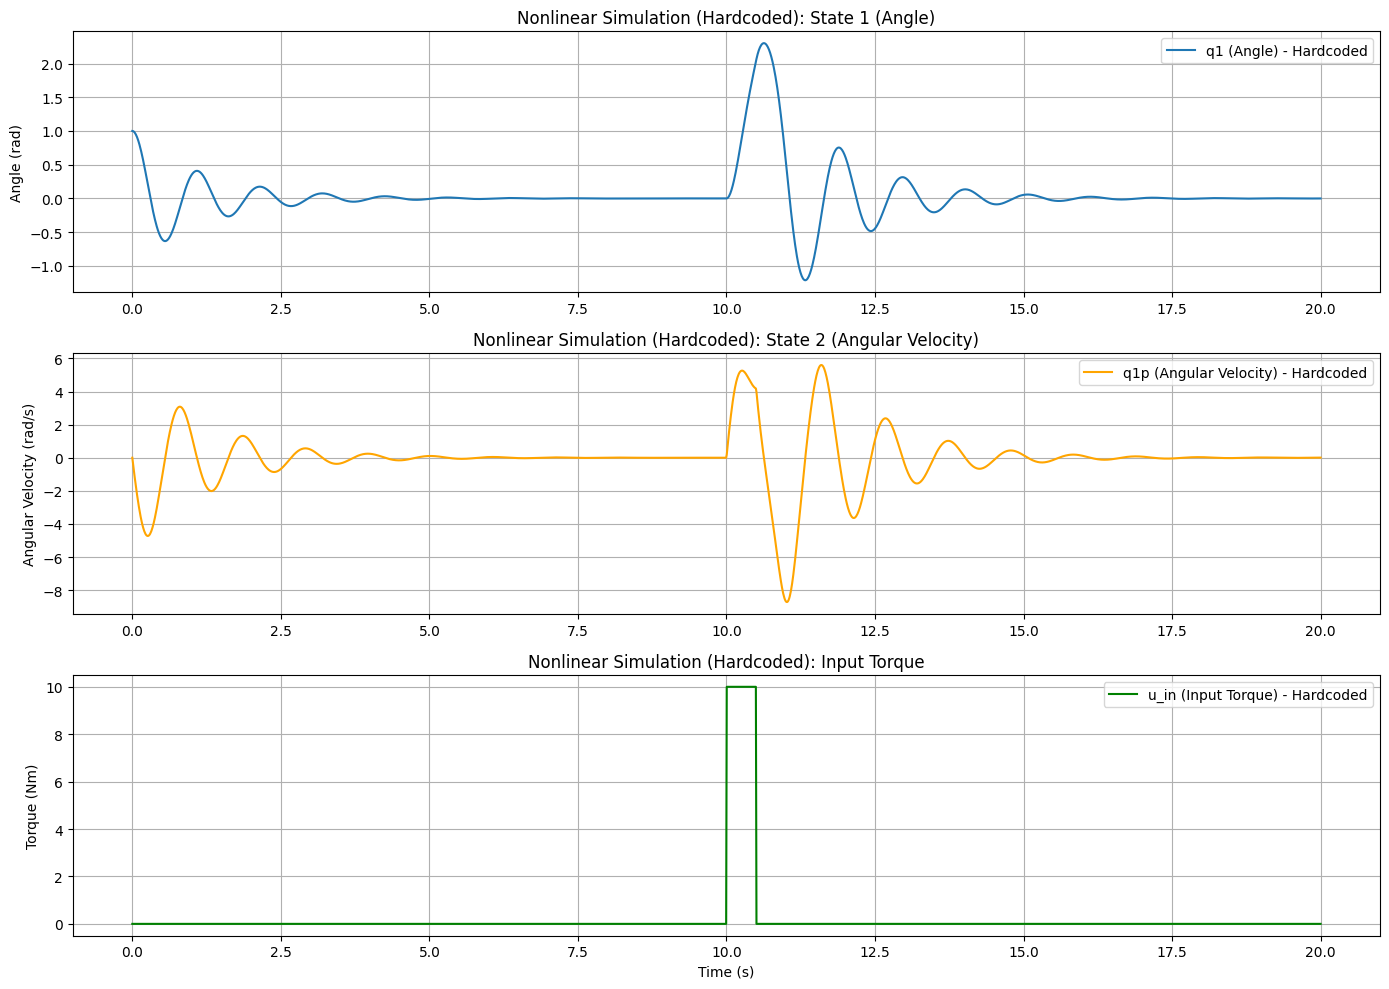

In [47]:
print("--- 8b. Plotting Nonlinear Simulation Results (Hardcoded) ---")

plt.figure(figsize=(14, 10))

# Plot State 1 (q1_s - angle)
plt.subplot(3, 1, 1)
plt.plot(t_hardcoded, x_hardcoded[:, 0], label='q1 (Angle) - Hardcoded')
plt.title('Nonlinear Simulation (Hardcoded): State 1 (Angle)')
plt.ylabel('Angle (rad)')
plt.grid(True)
plt.legend()

# Plot State 2 (q1p_s - angular velocity)
plt.subplot(3, 1, 2)
plt.plot(t_hardcoded, x_hardcoded[:, 1], label='q1p (Angular Velocity) - Hardcoded', color='orange')
plt.title('Nonlinear Simulation (Hardcoded): State 2 (Angular Velocity)')
plt.ylabel('Angular Velocity (rad/s)')
plt.grid(True)
plt.legend()

# Plot Input (u_in - motor command)
plt.subplot(3, 1, 3)
plt.plot(t_hardcoded, u_hardcoded, label='u_in (Input Torque) - Hardcoded', color='green')
plt.title('Nonlinear Simulation (Hardcoded): Input Torque')
plt.xlabel('Time (s)')
plt.ylabel('Torque (Nm)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()